In [2]:
import os
import cmocean.cm as cm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
bp='/Data/skd/projects/global/cmip6_precursors/outputs/terms/'
models=np.sort(os.listdir(bp))
models

array(['ACCESS-CM2', 'BCC-ESM1', 'CESM2', 'CNRM-CM6-1', 'CanESM5',
       'GFDL-CM4', 'IPSL-CM6A-LR', 'MIROC6', 'NorESM2-LM', 'NorESM2-MM'],
      dtype='<U12')

In [3]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Wedge
import matplotlib.patches as mpatches
import matplotlib.transforms as mtransforms

import matplotlib.colors as mcolors

def lighten_color(color, amount=0.2):
    """Lighten color by blending with white."""
    c = np.array(mcolors.to_rgb(color))
    return tuple(1 - amount * (1 - c))


def add_categories(a,boundary_ratio,minimal_thresh):
    clist=['xkcd:powder blue','xkcd:sand','#c5b5d4','#de7f8b','xkcd:seafoam green']
    edge_c='k'
    v=100
    rr=minimal_thresh*2**-0.5
    theta=np.rad2deg(np.tan(boundary_ratio))


    h1=a.add_patch(Wedge((0,0),v*2**0.5,-theta-90,theta-90,facecolor=clist[0],edgecolor=edge_c,zorder=1,linewidth=2,label='Dynamical Bias'))
    h2=a.add_patch(Wedge((0,0),v*2**0.5,-theta-270,theta-270,facecolor=clist[0],edgecolor=edge_c,zorder=1,linewidth=2,label='_'))
    h3=a.add_patch(Wedge((0,0),v*2**0.5,-theta,theta,facecolor=clist[1],edgecolor=edge_c,zorder=1,linewidth=2,label='Conversion Bias'))
    h4=a.add_patch(Wedge((0,0),v*2**0.5,-theta-180,theta-180,facecolor=clist[1],edgecolor=edge_c,zorder=1,linewidth=2,label='_'))
    h5=a.add_patch(plt.Rectangle((0,0), v,v, facecolor=clist[2],edgecolor=edge_c,zorder=0,linewidth=2,label='Compounding Bias'))
    h6=a.add_patch(plt.Rectangle((0,0), -v,-v, facecolor=clist[2],edgecolor=edge_c,zorder=0,linewidth=2,label='_'))
    h7=a.add_patch(plt.Rectangle((0,0), v,-v, facecolor=clist[3],edgecolor=edge_c,zorder=0,linewidth=2,label='Compensating Bias'))
    h8=a.add_patch(plt.Rectangle((0,0), -v,v, facecolor=clist[3],edgecolor=edge_c,zorder=0,linewidth=2,label='_'))
    rr=20
    rr=rr*2**-0.5
    minimal_patch=a.add_patch(plt.Rectangle((-rr,-rr), 2*rr, 2*rr,angle=45,rotation_point=(0,0),
                            facecolor=clist[4],edgecolor=edge_c,zorder=1,linewidth=2,label='Minimal Bias'))
    
    dyn_patches=[h1,h2]
    cnv_patches=[h3,h4]
    cmp_patches=[h5,h6]
    can_patches=[h7,h8]
    
    #add grey dashed lines on negative diagonals
    for dv in [-60,0,60]:
        a.plot([-v,v],[v+dv,-v+dv],c='gray',zorder=1,linestyle=':')

    #add grey diamonds
    for rr in 100*np.array(np.arange(0.2,2.41,0.2)):
            rr=rr*2**-0.5
            a.add_patch(plt.Rectangle((-rr,-rr), 2*rr, 2*rr,angle=45,rotation_point=(0,0),edgecolor='gray',label='_',facecolor='none'))

    return dyn_patches,cnv_patches,cmp_patches,can_patches,minimal_patch

def prepare_mean_dataframe(
    df,
    x_vars_to_sum,
    y_vars_to_sum,
    models=None,
    seasons=None,
    regions=None,
    term="bias",
    ens=False
):
    d = df.copy()

    # ---- Filtering ----
    if models is not None:
        d = d[d["model"].isin(models)]
    if seasons is not None:
        d = d[d["season"].isin(seasons)]
    if regions is not None:
        d = d[d["region_id"].isin(regions)]

    d = d[d["term"] == term]

    if ens:
        indexes=["model", "season", "region_id","member"]
    else:
        indexes=["model", "season", "region_id"]
    # ---- Pivot so sources become columns ----
    wide = d.pivot_table(
        index=indexes,
        columns="source",
        values="value",
        aggfunc="sum"
    ).reset_index()

    # ---- Compute x and y ----
    wide["xval"] = wide[x_vars_to_sum].sum(axis=1)
    wide["yval"] = wide[y_vars_to_sum].sum(axis=1)
    return wide

def get_model_markers(models):
    markers = ["o", "s", "^", "D", "v", "P", "X"]
    return {m: markers[i % len(markers)] for i, m in enumerate(models)}

def get_season_colors(seasons):
    #cmap = plt.get_cmap("tab10")

    colors=dict(DJF='tab:blue',
    MAM='tab:green',
    JJA='tab:red',
    SON='tab:orange'
    )

    return {s: colors[s] for s in seasons}#{s: cmap(i) for i, s in enumerate(seasons)}

def get_model_colors(models):
    model_colors={
       'CESM2':'tab:blue',
        'MPI-GE':'tab:red',
        'ACCESS-CM2':'darkgoldenrod',
        'BCC-ESM1':'slategray',
        'CNRM-CM6-1':'salmon',
        'GFDL-CM4':'olivedrab',
        'MIROC6':'deeppink',
        'NorESM2-LM':'mediumorchid',
        'NorESM2-MM':'rebeccapurple',
        'IPSL-CM6A-LR':'tab:green',
        'CanESM5':'tab:orange'
    }
    return {m: model_colors[m] for m in models}

def get_region_colors(regions, base_color=None):
    cmap = plt.get_cmap("tab10")
    if base_color is None:
        return {r: cmap(i) for i, r in enumerate(regions)}
    else:
        # vary lightness of base color
        return {r: lighten_color(base_color, 1 - 0.8*i/len(regions))
                for i, r in enumerate(regions)}

def _add_scatter(ax, wide, style,base_color='tab:blue'):
    model_markers = get_model_markers(wide["model"].unique())
    season_colors = get_season_colors(wide["season"].unique())
    model_colors = get_model_colors(wide["model"].unique())

    regions = wide["region_id"].unique()

    multi_season = len(season_colors) > 1
    multi_region = len(regions) > 1
    multi_model = len(model_markers) > 1

    #set colors for data points:

    # by season
    if multi_season:
        #or region, hue set by season
        if multi_region:
            colors = [get_region_colors(regions, base_color=season_colors[s])[r] for s,r in zip(wide['season'],wide['region_id'])]
        else:
            colors = [season_colors[x] for x in wide["season"]]

    #or by region only
    elif multi_region:
            colors = [get_region_colors(regions)[r] for r in wide['region_id']]
    #or else by model
    elif multi_model:
        colors = [model_colors[x] for x in wide['model']]
    #or finally, fixed
    else:
        colors=[base_color for _ in wide['xval']]


    wide['_plot_color']=colors
    for i, r in wide.iterrows():

        ax.scatter(
            r["xval"], r["yval"],
            color=r["_plot_color"],
            marker=model_markers[r["model"]],
            **style
        )

    return model_markers, season_colors, regions, wide
    
def add_mean_scatter(ax, wide):
    style = dict(edgecolors="w", s=100, alpha=1, zorder=50)
    return _add_scatter(ax, wide, style)

def add_ens_scatter(ax, wide):
    style = dict(s=20, edgecolors="k", linewidths=0.3, alpha=0.95)
    return _add_scatter(ax, wide, style)

def add_uncertainty_ellipses(ax, wide, mean_colors, n_std=3):

    for _, r in wide.iterrows():
        # correlation ellipse base radii
        ell_radius_x = np.sqrt(1 + r["pcorr"])
        ell_radius_y = np.sqrt(1 - r["pcorr"])

        ellipse = mpatches.Ellipse(
            (0, 0),
            width=ell_radius_x * 2,
            height=ell_radius_y * 2,
            facecolor="none",
            lw=2,
            edgecolor=r["_plot_color"],
            zorder=20,
        )

        scale_x = r["xstd"] * n_std
        scale_y = r["ystd"] * n_std

        transf = (
            mtransforms.Affine2D()
            .rotate_deg(45)
            .scale(scale_x, scale_y)
            .translate(r["xval"], r["yval"])
        )

        ellipse.set_transform(transf + ax.transData)
        ax.add_patch(ellipse)

def attach_uncertainty(wide, std_df, x_vars_to_sum, y_vars_to_sum,
                       models=None, seasons=None, regions=None, term="bias"):

    # ---- Build variable names ----
    xstd = "std_" + "+".join(x_vars_to_sum)
    ystd = "std_" + "+".join(y_vars_to_sum)
    corr = "corr_" + "_".join(["+".join(y_vars_to_sum), "+".join(x_vars_to_sum)])

    # ---- Filter std_df exactly like mean df ----
    std_d = std_df.copy()
    if models is not None:
        std_d = std_d[std_d["model"].isin(models)]
    if seasons is not None:
        std_d = std_d[std_d["season"].isin(seasons)]
    if regions is not None:
        std_d = std_d[std_d["region_id"].isin(regions)]

    std_d = std_d[std_d["term"] == term]

    # ---- Keep only needed columns ----
    std_d = std_d[["model", "season", "region_id", xstd, ystd, corr]]

    # ---- Merge (safe!) ----
    wide = wide.merge(std_d, on=["model", "season", "region_id"], how="left")

    # ---- Rename for plotting convenience ----
    wide = wide.rename(columns={xstd: "xstd", ystd: "ystd", corr: "pcorr"})

    return wide

from matplotlib.lines import Line2D

def attach_labels(ax, x_vars_to_sum, y_vars_to_sum, term,
                  wide, model_markers, mean_colors, regions, has_ens=False):

    short_vars = dict(dynamical='dyn', conversion='conv', nonlinear='NL')

    # ---- Axis labels ----
    xlonlab = "+".join(x_vars_to_sum).capitalize()
    xshortlab = "+".join([short_vars[xv.lower()] for xv in x_vars_to_sum])
    xlabel = fr'$b_\text{{{xshortlab}}}$, {xlonlab} {term} (relative %)'
    ax.set_xlabel(xlabel)

    ylonlab = "+".join(y_vars_to_sum).capitalize()
    yshortlab = "+".join([short_vars[yv.lower()] for yv in y_vars_to_sum])
    ylabel = fr'$b_\text{{{yshortlab}}}$, {ylonlab} {term} (relative %)'
    ax.set_ylabel(ylabel)

    season_handles = []
    model_handles = []
    region_handles = []
    size_handles = []

    # Determine dimensionality
    multi_season = len(mean_colors) > 1
    multi_region = len(regions) > 1
    multi_model = len(model_markers) > 1
    # ---- Seasons and/or Regions ----
    if multi_season and multi_region:
        # Both season and region vary: create handles using actual colors from wide
        # Get unique season-region pairs that appear in the data
        unique_pairs = wide[['season', 'region_id', '_plot_color']].drop_duplicates().sort_values(['season', 'region_id'])
        for _, row in unique_pairs.iterrows():
            season_handles.append(
                Line2D([0],[0], marker='o', color='w',
                       markerfacecolor=row['_plot_color'], 
                       label=f"{row['season']} Region {row['region_id']}", markersize=8)
            )
    elif multi_season:
        # Only season varies
        season_handles = [
            Line2D([0],[0], marker='o', color='w',
                   markerfacecolor=mean_colors[s], label=s, markersize=8)
            for s in mean_colors
        ]
    elif multi_region:
        # Only region varies
        reg_colors = get_region_colors(regions)
        region_handles = [
            Line2D([0],[0], marker='o', color='w',
                   markerfacecolor=reg_colors[r], label=f"Region {r}", markersize=8)
            for r in regions
        ]

    # ---- Models ----
    if multi_model:
        if not multi_season and not multi_region:
            model_colors = get_model_colors(model_markers)
        else: 
            model_colors= {m:'k' for m in model_markers}
        model_handles = [
            Line2D([0],[0], marker=model_markers[m], color=model_colors[m],
                   linestyle='None', label=m, markersize=8)
            for m in model_markers
        ]

    # ---- Mean vs ensemble ----
    if has_ens:
        size_handles = [
            Line2D([0],[0], marker='o', color='k', linestyle='None',
                   markersize=10, label="Mean"),
            Line2D([0],[0], marker='o', color='k', linestyle='None',
                   markersize=4, label="Ensemble member"),
        ]

    handles = season_handles + region_handles + model_handles + size_handles

    if handles:
        ax.legend(handles=handles, frameon=True)

def add_rosette(ax,xvars,yvars,mean_df,ens_df=None,boot_df=None,models=None,seasons=None,regions=None,term='bias',br=0.2,minthresh=0.2,n_std=2):

    wide = prepare_mean_dataframe(mean_df, xvars, yvars,
                                models, seasons, regions, term)

    # colors for ellipses
    season_colors = get_season_colors(wide["season"].unique())
    wide["color"] = wide["season"].map(season_colors)

    #background
    handles=add_categories(ax,br,minthresh)
    # scatter
    mean_markers, mean_colors, regions, wide = add_mean_scatter(ax, wide)
    ens_markers = ens_colors = None
    has_ens = False
    if ens_df is not None:
        ens_wide = prepare_mean_dataframe(ens_df, xvars, yvars,
                                        models, seasons, regions, term,
                                        ens=True)
        ens_markers, ens_colors,regions,ens_wide = add_ens_scatter(ax, ens_wide)
        has_ens = True

    # Mean uncertainty
    if boot_df is not None:
        wide = attach_uncertainty(wide, boot_df,
                                xvars, yvars,
                                models, seasons, regions, term)
        add_uncertainty_ellipses(ax, wide, mean_colors,n_std=n_std)

    #labels
    attach_labels(ax, xvars, yvars, term,
                wide, mean_markers, mean_colors, regions, has_ens=has_ens)    
    return


def get_category_label_on_df(df,x_dims=['conversion'],y_dims=['dynamical','nonlinear'],br=0.2, me=20):
    x_df=[df.query(f"source=='{dim}'") for dim in x_dims]
    y_df=[df.query(f"source=='{dim}'") for dim in y_dims]

    #now add each df in x_df together where numeric and otherwise keep the first value:

    from functools import reduce
    adder=lambda a,b: a['value'].values + b['value'].values
    x_vals= reduce(adder, x_df)
    y_vals= reduce(adder,y_df)
    x_vals= x_vals if x_vals.ndim==1 else x_vals['value']
    y_vals= y_vals if y_vals.ndim==1 else y_vals['value']
    x_vals=np.array(x_vals)
    y_vals=np.array(y_vals)

    br=0.2
    me=20

    is_cancelling=np.logical_xor((x_vals>0),(y_vals>0))
    slope=abs(y_vals/x_vals)
    is_therm=slope<=br
    is_dyn=slope>=1/br
    is_min=(abs(x_vals)+abs(y_vals))<=me
    label=is_cancelling.astype(int)+2
    label[is_dyn]=0
    label[is_therm]=1
    label[is_min]=4

    plot_df=x_df[0].copy()
    plot_df['label']=label
    plot_df['x_val']=x_vals
    plot_df['y_val']=y_vals
    return plot_df


def df_to_plottable_map(df,variable,query_dict,M,Maux):

    query_string=' and '.join([f"{k}=='{v}'" for k,v in query_dict.items()])
    ds=df.query(query_string).set_index('region_id').to_xarray()
    return ds[variable].sel(region_id=Maux,method='bfill').where(~np.isnan(M))

def mask_dry_values(df, is_dry_case, value_col="value"):
    out = df.copy()

    # Build lookup Series indexed by (season, region_id)
    dry_lookup = is_dry_case.to_series()
    dry_lookup.index = dry_lookup.index.set_names(["region_id", "season"])

    # Align each row in df to lookup
    row_index = pd.MultiIndex.from_frame(out[["region_id", "season"]])
    dry_mask = dry_lookup.reindex(row_index).fillna(False).to_numpy()

    # Mask values where dry case is True
    out.loc[dry_mask, value_col] = np.nan
    return out



# First we do a bias analysis. For this we want ensemble means, and historical members.

## Our questions are: 
* how varied are biases between models?
* Are there systematic problem areas for models? This is particularly interesting for dynamics.


## Data setup

In [3]:
full_ens_models=['IPSL-CM6A-LR','CanESM5', 'CESM2']
hist_ens_models=['NorESM2-LM','NorESM2-MM']
single_models=['ACCESS-CM2']
hist_single_models=['BCC-ESM1', 'GFDL-CM4','MIROC6']
cnrm='CNRM-CM6-1'

In [4]:
ens_tc=dict(
    full_ens='historical_ens_ssp370_ens',
    hist_ens='historical_ens_ssp370_r1i1p1f1',
    single='historical_r1i1p1f1_ssp370_r1i1p1f1',
    hist_single='historical_r1i1p1f1',
    cnrm='historical_r2i1p1f2_ssp370_r1i1p1f2'
)

model_categories=dict(
    full_ens=['IPSL-CM6A-LR','CanESM5','CESM2'],
    hist_ens=['NorESM2-LM','NorESM2-MM'],
    single=['ACCESS-CM2','MIROC6'],
    hist_single=['BCC-ESM1', 'GFDL-CM4'],
    cnrm=['CNRM-CM6-1']
)

In [136]:
M=xr.open_dataarray('/Data/gfi/users/jodor4442/rainfall_regions/K39_ERA5land_lat_weighted_2d_direct.nc')
Maux=M.where(M!=2).fillna(1).astype(int)

era5_thresholds=xr.open_dataarray('/Data/gfi/users/jodor4442/era5_p95_thresholds.nc')
is_dry_case=era5_thresholds<0.0025


In [195]:
ensemble_means=[]

for key in ens_tc:
    for m in model_categories[key]:
        term_file=os.path.join(bp,m,ens_tc[key],f'{m}_{ens_tc[key]}_paper_terms_df.csv')
        if not os.path.exists(term_file):
            print(f'NO FILE FOR {term_file}, SKIPPING')
            continue
        terms=pd.read_csv(term_file,index_col=0)
        ensemble_means.append(terms)
ensemble_means=pd.concat(ensemble_means,ignore_index=True)

In [196]:
ensemble_members={}
for m in models:
    files=[f for f in os.listdir(os.path.join(bp,m)) if f.find('ens')==-1]
    #drop elements of files that are a substring of another element in files:
    tcs=[f for f in files if not any(f!=g and f in g for g in files)]
    tc_arr=[]
    for tc in tcs:
        term_file=os.path.join(bp,m,tc,f'{m}_{tc}_paper_terms_df.csv')
        if not os.path.exists(term_file):
            print(f'NO FILE FOR {term_file}, SKIPPING')
            continue
        terms=pd.read_csv(term_file,index_col=0)
        tc_arr.append(terms)
    #now combine all dataframes in tc_arr into a single dataframe, and store in ensemble_members[m]
    ensemble_members[m]=pd.concat(tc_arr,ignore_index=True)
ensemble_members=pd.concat([ensemble_members[m] for m in ensemble_members],ignore_index=True)

In [204]:
ensemble_means=mask_dry_values(ensemble_means, is_dry_case)
ensemble_members=mask_dry_values(ensemble_members, is_dry_case)

In [205]:
scale_coeff=100 /0.05 # as percentage of reference event probability
ensemble_means['value']*=scale_coeff
ensemble_members['value']*=scale_coeff

category_df=get_category_label_on_df(ensemble_means)
ens_category_df=get_category_label_on_df(ensemble_members)

# 'Rosette plot' plotting examples

Text(0.5, 1.0, 'DJF Low Countries Biases')

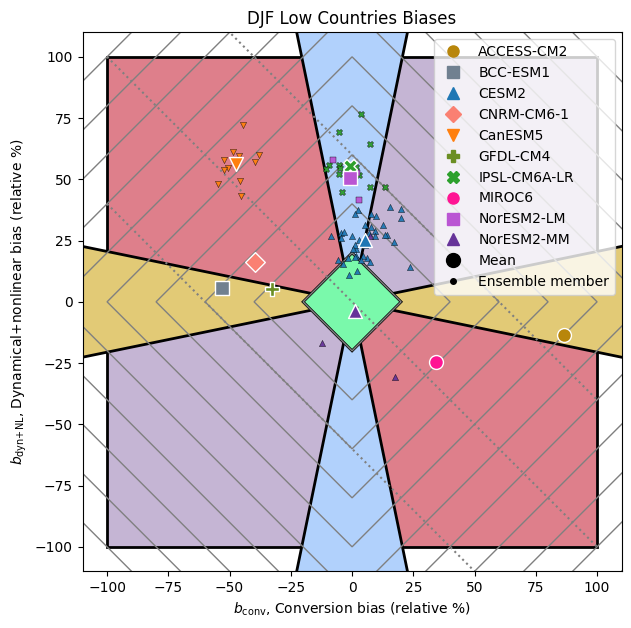

In [206]:
fig, ax = plt.subplots()
fig.set_figwidth(7)
fig.set_figheight(7)
ax.set_xlim(-110, 110)
ax.set_ylim(-110, 110)
ax.set_aspect(1)


xvars=['conversion']
yvars=['dynamical','nonlinear']
add_rosette(
    ax,xvars,yvars,
    mean_df=ensemble_means.drop(columns=['member']),ens_df=ensemble_members,
    seasons=['DJF'],
    regions=[34],
    term='bias')
ax.set_title('DJF Low Countries Biases')

Text(0.5, 1.0, 'CESM2 Biases by Season, Low Countries')

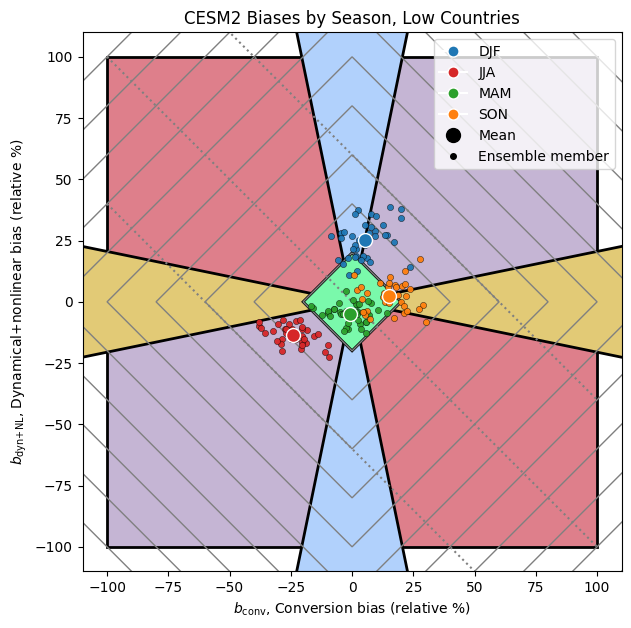

In [207]:
fig, ax = plt.subplots()
fig.set_figwidth(7)
fig.set_figheight(7)
ax.set_xlim(-110, 110)
ax.set_ylim(-110, 110)
ax.set_aspect(1)


xvars=['conversion']
yvars=['dynamical','nonlinear']
add_rosette(
    ax,xvars,yvars,
    mean_df=ensemble_means.drop(columns=['member']),ens_df=ensemble_members,
    seasons=['DJF','MAM','JJA','SON'],
    regions=[34],
    models=['CESM2'],
    term='bias')
ax.set_title('CESM2 Biases by Season, Low Countries')

# Map plotting examples

In [240]:
df_to_default_map =lambda ds, query_dict: df_to_plottable_map(ds,query_dict=query_dict,
                                    variable='value',M=M,Maux=Maux)
df_to_category_map =lambda ds, query_dict: df_to_plottable_map(ds,query_dict=query_dict,
                                    variable='label',M=M,Maux=Maux)

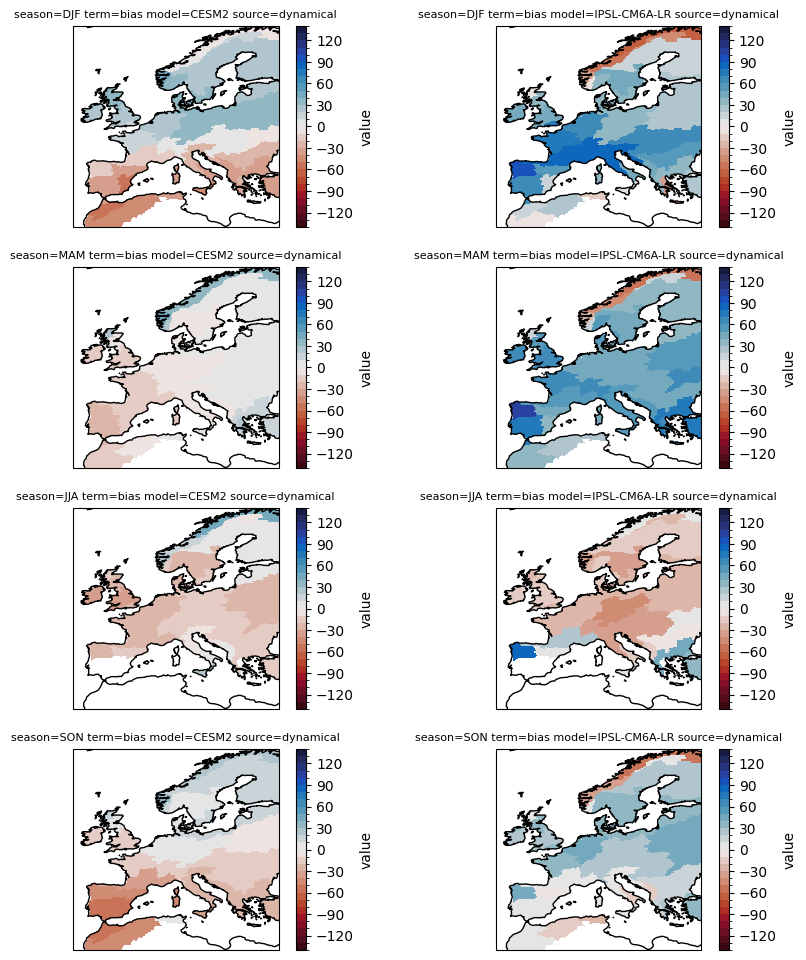

In [238]:
ds=ensemble_means
sel_dicts=[
        {'season':s,'term':'bias','model':m, 'source': 'dynamical'}
        for s in ['DJF','MAM','JJA','SON'] 
        for m in ['CESM2','IPSL-CM6A-LR']]

cmap = cm.balance_r
cmap.set_bad('white')

fig,axes=plt.subplots(4,2,transform=ccrs.PlateCarree,subplot_kw={'projection': ccrs.PlateCarree()})
fig.set_figwidth(10)
fig.set_figheight(12)


for a,sel_dict in zip(axes.flatten(),sel_dicts):
    ds_map=df_to_default_map(ds,query_dict=sel_dict)
    p = ds_map.plot(
        cmap=cmap,
        transform=ccrs.PlateCarree(),  # <- specify transform of your data
        add_colorbar=True,
        vmin=-100,vmax=100,levels=np.arange(-140,140.1,10),
        ax=a
    )
    a.coastlines(color='black')
    a.set_title(' '.join([f"{k}={v}" for k,v in sel_dict.items()]),fontsize=8)


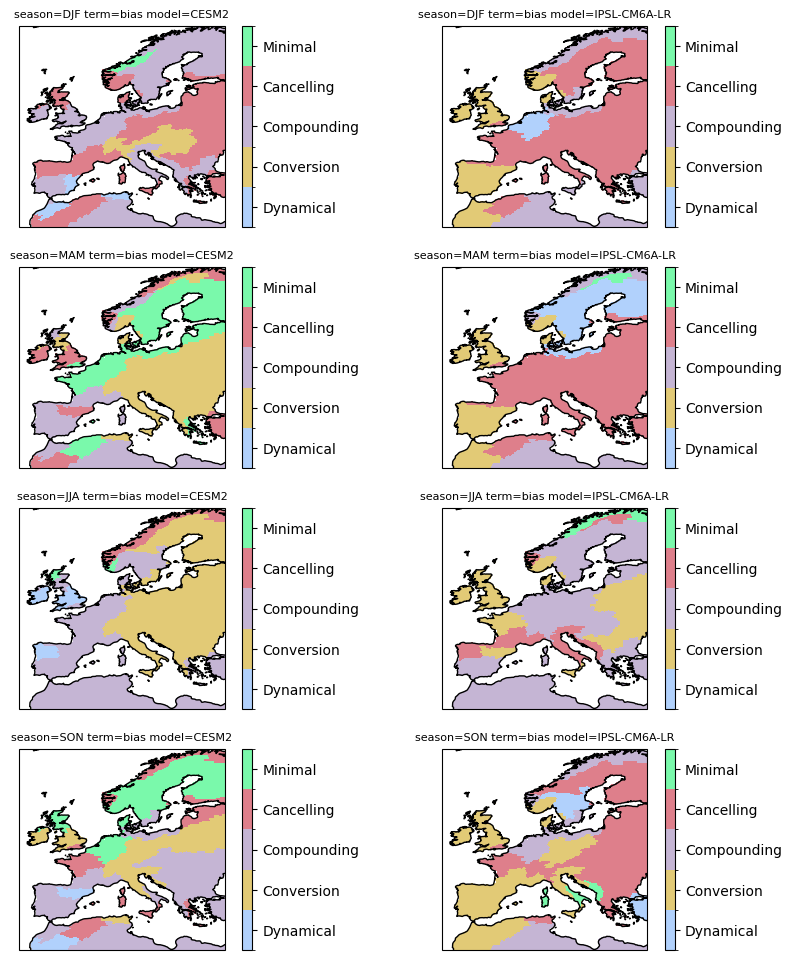

In [245]:
from matplotlib.colors import LinearSegmentedColormap
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
clist=['xkcd:powder blue','xkcd:sand','#c5b5d4','#de7f8b','xkcd:seafoam green']


ds=category_df
sel_dicts=[
        {'season':s,'term':'bias','model':m}
        for s in ['DJF','MAM','JJA','SON'] 
        for m in ['CESM2','IPSL-CM6A-LR']]

cmap = LinearSegmentedColormap.from_list("bias_map", clist, N=5)
cmap.set_bad('white')

fig,axes=plt.subplots(4,2,transform=ccrs.PlateCarree,subplot_kw={'projection': ccrs.PlateCarree()})
fig.set_figwidth(10)
fig.set_figheight(12)


for a,sel_dict in zip(axes.flatten(),sel_dicts):
    ds_map=df_to_category_map(ds,query_dict=sel_dict)
    p = ds_map.plot(
        cmap=cmap,
        transform=ccrs.PlateCarree(),  # <- specify transform of your data
        add_colorbar=True,
        levels=[-0.5,0.5, 1.5, 2.5, 3.5, 4.5],
        ax=a
    )
    a.coastlines(color='black')
    a.set_title(' '.join([f"{k}={v}" for k,v in sel_dict.items()]),fontsize=8)
    cbar=fig.axes[-1]
    cbar.set_yticks([0,1,2,3,4],['Dynamical','Conversion','Compounding','Cancelling','Minimal'])
    cbar.set_ylabel('')


# Histograms

<Axes: xlabel='value', ylabel='Count'>

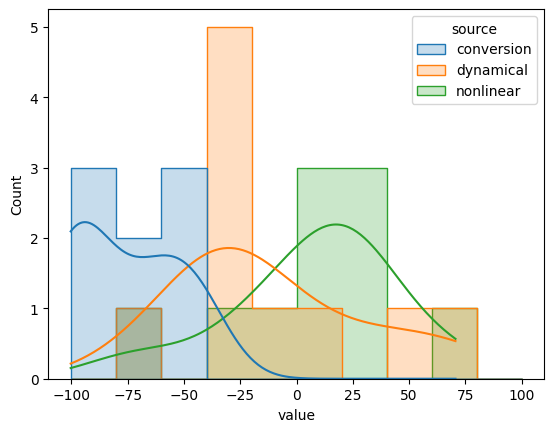

In [258]:
filtered_ds=ensemble_means.query(
    "term=='bias' and season == 'DJF' and region_id ==14")

import seaborn as sns

sns.histplot(data=filtered_ds, x='value',hue='source',element='step',fill=True,kde=True,bins=np.arange(-100,101,20))

<Axes: xlabel='value', ylabel='Count'>

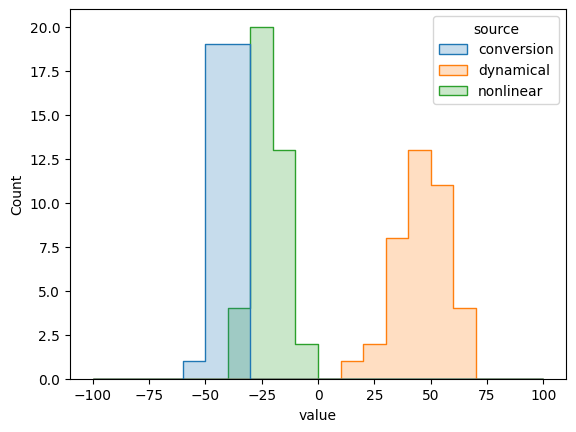

In [261]:
filtered_ds=ensemble_members.query(
    "term=='bias' and season == 'DJF' and region_id ==14 and model=='CESM2'")

import seaborn as sns

sns.histplot(data=filtered_ds, x='value',hue='source',element='step',
             fill=True,bins=np.arange(-100,101,10))

In [ ]:
keep_cols=['season','region_id','value','model','member']
conv_terms=ensemble_means.query("term=='bias' and source=='conversion'")[keep_cols]
dyn_terms=ensemble_means.query("term=='bias' and source=='dynamical'")[keep_cols]
nl_terms=ensemble_means.query("term=='bias' and source=='nonlinear'")[keep_cols]

dyn_nl_terms=dyn_terms['value'].reset_index()+nl_terms['value'].reset_index()
terms=conv_terms.copy().reset_index().rename(columns={'value':'conv'})
terms['dyn']=dyn_terms['value'].reset_index()['value']
terms['nl']=nl_terms['value'].reset_index()['value']
terms['dyn_nl']=dyn_nl_terms['value']

#Some metrics I was playing with, not sure how informative they are.
terms['nonlinearity']=terms['nl']/(terms['dyn_nl'])
terms['angle']=np.rad2deg(np.arctan2(terms['conv'],terms['dyn_nl']))
terms['amp']=abs(terms['conv'])+abs(terms['dyn_nl'])
terms['apparent_err']=(terms['conv']+terms['dyn_nl'])
terms['err_ratio']=-1 + 4*np.arctan(terms['amp']/abs(terms['conv']+terms['dyn_nl']))/np.pi #0 means perfect, 1 means no apparent but large actual.

